# H1: fitting f_N vs N (constant vs power-law correction)

Careful analysis tied to a specific result -- pinned to run
`frozen_fraction_production_20260912T074229Z`
(N = 100..102400, target relative SE = 1%, all realizations converged).

Two models, both fit by weighted least squares using the per-N standard
errors (sigma_N = SE) already computed by the ensemble:

- **Model 1 (constant):** f(N) = f_inf  (1 parameter)
- **Model 2 (power-law correction):** f(N) = f_inf + a / N^alpha  (3 parameters)

chi^2 = sum( ((f_N - model(N)) / sigma_N)^2 ), reduced chi^2 = chi^2 / dof,
dof = (number of points) - (number of parameters).

This is presented as-is -- no claim here about which model is "correct";
that's for RESULTS.md / the researcher to decide.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

RUN_DIR = Path('../../data/raw/frozen_fraction_production_20260912T074229Z')

with open(RUN_DIR / 'summary.json') as f:
    summary = json.load(f)
summary = sorted(summary, key=lambda row: row['L'])

N = np.array([row['L'] for row in summary], dtype=float)
f = np.array([row['frozen_fraction_mean'] for row in summary])
se = np.array([row['frozen_fraction_se'] for row in summary])

for n_i, f_i, se_i in zip(N, f, se):
    print(f"N={int(n_i):6d}  f_N={f_i:.4f} +- {se_i:.4f}")

N=   100  f_N=0.3490 +- 0.0035
N=   200  f_N=0.3523 +- 0.0035
N=   400  f_N=0.3567 +- 0.0034
N=   800  f_N=0.3640 +- 0.0036
N=  1600  f_N=0.3638 +- 0.0034
N=  3200  f_N=0.3603 +- 0.0032
N=  6400  f_N=0.3605 +- 0.0036
N= 12800  f_N=0.3621 +- 0.0033
N= 25600  f_N=0.3615 +- 0.0016
N= 51200  f_N=0.3606 +- 0.0013
N=102400  f_N=0.3580 +- 0.0010


In [2]:
def chi_square(f_obs, f_model, sigma):
    return np.sum(((f_obs - f_model) / sigma) ** 2)

n_points = len(N)

# --- Model 1: constant f_inf ---
# Weighted least squares for a constant is the inverse-variance-weighted mean.
weights = 1.0 / se**2
f_inf_const = np.sum(f * weights) / np.sum(weights)
f_inf_const_err = np.sqrt(1.0 / np.sum(weights))

model1_pred = np.full_like(f, f_inf_const)
model1_resid = f - model1_pred
model1_chi2 = chi_square(f, model1_pred, se)
model1_dof = n_points - 1
model1_red_chi2 = model1_chi2 / model1_dof

print('Model 1: constant f(N) = f_inf')
print(f'  f_inf = {f_inf_const:.5f} +- {f_inf_const_err:.5f}')
print(f'  chi^2 = {model1_chi2:.3f}, dof = {model1_dof}, reduced chi^2 = {model1_red_chi2:.3f}')
print('  residuals (f_N - f_inf):')
for n_i, r_i in zip(N, model1_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 1: constant f(N) = f_inf
  f_inf = 0.35923 +- 0.00060
  chi^2 = 22.673, dof = 10, reduced chi^2 = 2.267
  residuals (f_N - f_inf):
    N=   100  residual=-0.01024
    N=   200  residual=-0.00694
    N=   400  residual=-0.00252
    N=   800  residual=+0.00478
    N=  1600  residual=+0.00456
    N=  3200  residual=+0.00105
    N=  6400  residual=+0.00124
    N= 12800  residual=+0.00290
    N= 25600  residual=+0.00229
    N= 51200  residual=+0.00142
    N=102400  residual=-0.00126


In [3]:
# --- Model 2: f_inf + a / N^alpha ---
def model2(n, f_inf, a, alpha):
    return f_inf + a / n**alpha

p0 = [f_inf_const, f[0] - f_inf_const, 1.0]
popt, pcov = curve_fit(model2, N, f, p0=p0, sigma=se, absolute_sigma=True, maxfev=20000)
f_inf_m2, a_m2, alpha_m2 = popt
perr = np.sqrt(np.diag(pcov))

model2_pred = model2(N, *popt)
model2_resid = f - model2_pred
model2_chi2 = chi_square(f, model2_pred, se)
model2_dof = n_points - 3
model2_red_chi2 = model2_chi2 / model2_dof

print('Model 2: f(N) = f_inf + a / N^alpha')
print(f'  f_inf = {f_inf_m2:.5f} +- {perr[0]:.5f}')
print(f'  a     = {a_m2:.5f} +- {perr[1]:.5f}')
print(f'  alpha = {alpha_m2:.5f} +- {perr[2]:.5f}')
print(f'  chi^2 = {model2_chi2:.3f}, dof = {model2_dof}, reduced chi^2 = {model2_red_chi2:.3f}')
print('  residuals (f_N - model2(N)):')
for n_i, r_i in zip(N, model2_resid):
    print(f'    N={int(n_i):6d}  residual={r_i:+.5f}')

Model 2: f(N) = f_inf + a / N^alpha
  f_inf = 0.35983 +- 0.00066
  a     = -4.67391 +- 18.65138
  alpha = 1.30056 +- 0.84438
  chi^2 = 10.100, dof = 8, reduced chi^2 = 1.263
  residuals (f_N - model2(N)):
    N=   100  residual=+0.00088
    N=   200  residual=-0.00278
    N=   400  residual=-0.00119
    N=   800  residual=+0.00496
    N=  1600  residual=+0.00428
    N=  3200  residual=+0.00058
    N=  6400  residual=+0.00069
    N= 12800  residual=+0.00232
    N= 25600  residual=+0.00170
    N= 51200  residual=+0.00082
    N=102400  residual=-0.00186


/var/folders/z_/tgnxpvj92jl2bzxg09ltsgxr0000gn/T/ipykernel_4163/3864288346.py:3: RuntimeWarning: overflow encountered in power
  return f_inf + a / n**alpha


In [4]:
print(f"{'model':<10} {'params':<45} {'chi2':>8} {'dof':>4} {'red chi2':>9}")
print(f"{'constant':<10} {'f_inf='+format(f_inf_const,'.5f'):<45} {model1_chi2:8.3f} {model1_dof:4d} {model1_red_chi2:9.3f}")
params_str = f"f_inf={f_inf_m2:.5f}, a={a_m2:.5f}, alpha={alpha_m2:.5f}"
print(f"{'f_inf+a/N^a':<10} {params_str:<45} {model2_chi2:8.3f} {model2_dof:4d} {model2_red_chi2:9.3f}")

model      params                                            chi2  dof  red chi2
constant   f_inf=0.35923                                   22.673   10     2.267
f_inf+a/N^a f_inf=0.35983, a=-4.67391, alpha=1.30056        10.100    8     1.263


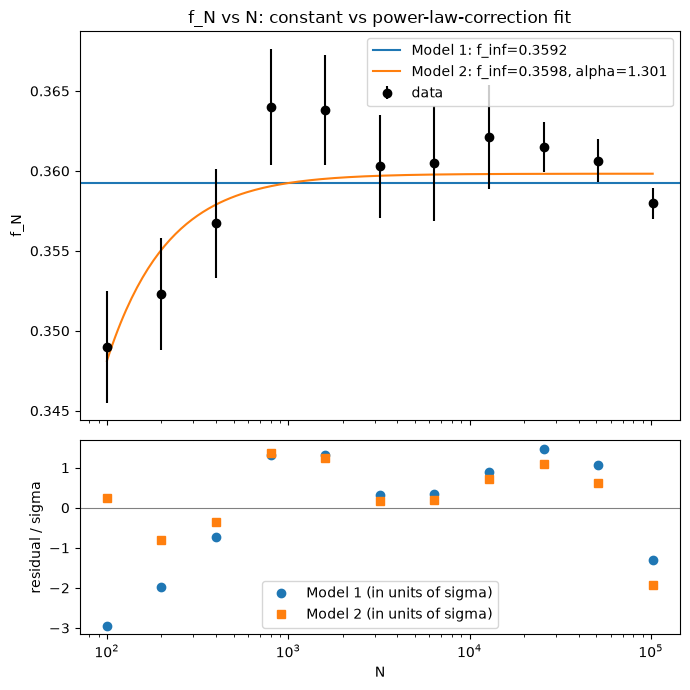

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True, height_ratios=[2, 1])

n_grid = np.geomspace(N.min(), N.max(), 200)

ax = axes[0]
ax.errorbar(N, f, yerr=se, fmt='o', color='black', label='data', zorder=3)
ax.axhline(f_inf_const, color='C0', label=f'Model 1: f_inf={f_inf_const:.4f}')
ax.plot(n_grid, model2(n_grid, *popt), color='C1',
        label=f'Model 2: f_inf={f_inf_m2:.4f}, alpha={alpha_m2:.3f}')
ax.set_xscale('log')
ax.set_ylabel('f_N')
ax.legend()
ax.set_title('f_N vs N: constant vs power-law-correction fit')

ax = axes[1]
ax.axhline(0, color='gray', linewidth=0.8)
ax.errorbar(N, model1_resid / se, fmt='o', color='C0', label='Model 1 (in units of sigma)')
ax.errorbar(N, model2_resid / se, fmt='s', color='C1', label='Model 2 (in units of sigma)')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('residual / sigma')
ax.legend()

fig.tight_layout()
plt.show()